# Boreal AGBD validation

*Notes on Plot Groups*
+ there has likely been change in:  
      + many of the 'West Siberian Plains' plots - according to manual check of Google Earth imagery  
      + some of the Tunguska River plots - fire?
+ I have questions about:  
      + Russian Far East plots - looks like Alnus recorded instead of Betula possibly? This results in a much lower plot-level (agbd_v2_mg_ha) which is calc'd from per-tree estimates, b/c we dont use Alnus allometry (its ignored)
+ cant use:  
      + Amur River plots - no biomass or tree info - just timber volume  
      + Changbai Mountains - not in boreal

--------------------------------------------------------------------------------
Author Information
--------------------------------------------------------------------------------
Name                    | Affiliation
------------------------|-------------------------------------------------------
Paul Montesano, Phd     | NASA GSFC, ESSIC

--------------------------------------------------------------------------------
Last Updated: 2026-05-12
--------------------------------------------------------------------------------

In [103]:
library(sf)
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)
library(reshape2)
library(viridis)
library(RColorBrewer)

In [122]:
today_date <- format(Sys.Date(), "%Y%m%d")

In [121]:
# Read the geopackage (adjust filename as needed)
filename <- '/projects/my-private-bucket/reference/eurasia_forest_structure_plots_agbd_20260513_20260513.gpkg'
plots_sf <- st_read(filename) %>% 
    filter(!group_name %in% c('West Siberian Plains', 'Russian Far East', 'Amur River'))

Reading layer `eurasia_forest_structure_plots_agbd_20260513_20260513' from data source `/projects/my-private-bucket/reference/eurasia_forest_structure_plots_agbd_20260513_20260513.gpkg' 
  using driver `GPKG'
Simple feature collection with 646 features and 80 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -4119546 ymin: 1830029 xmax: -2058208 ymax: 5249695
Projected CRS: unnamed


In [123]:
filename <- '/projects/my-private-bucket/reference/nfi_plus_20220603_20260513.geojson'
plots_sf <- st_read(filename) 

Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Message 1: File /projects/my-private-bucket/reference/nfi_plus_20220603_20260513.geojson has GPKG application_id, but non conformant file extension”


Reading layer `nfi_plus_20220603_20260513' from data source 
  `/projects/my-private-bucket/reference/nfi_plus_20220603_20260513.geojson' 
  using driver `GPKG'
Simple feature collection with 987 features and 144 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 1779906 ymin: 2523068 xmax: 5596937 ymax: 7452600
Projected CRS: unnamed


In [124]:
colnames(plots_sf) 

[1] "nfi_plot"                                        
  [2] "meas_date_x"                                     
  [3] "meas_num_x"                                      
  [4] "plot_completion"                                 
  [5] "incomp_reason"                                   
  [6] "province"                                        
  [7] "ecozone"                                         
  [8] "prov_eco_type"                                   
  [9] "prov_eco_ref"                                    
 [10] "utm_n"                                           
 [11] "utm_e"                                           
 [12] "utm_zone"                                        
 [13] "slope"                                           
 [14] "aspect"                                          
 [15] "elevation"                                       
 [16] "land_base"                                       
 [17] "land_cover"                                      
 [18] "land_pos"                                        
 [19] "veg_type"                                        
 [20] "density_cl"                                      
 [21] "stand_stru"                                      
 [22] "succ_stage"                                      
 [23] "wetland_class"                                   
 [24] "user_info"                                       
 [25] "ec_region"                                       
 [26] "ec_district"                                     
 [27] "plotvol_standlive"                               
 [28] "plotvol_standdead"                               
 [29] "plotvol_falllive"                                
 [30] "plotvol_smtr_live"                               
 [31] "plotvol_smtr_dead"                               
 [32] "grossvol_incr"                                   
 [33] "grossvol_mai"                                    
 [34] "plotvol_stump"                                   
 [35] "plotbio_stump"                                   
 [36] "plotbio_lgtr_live"                               
 [37] "plotbio_lgtr_dead"                               
 [38] "plotbio_smtr_live"                               
 [39] "plotbio_smtr_dead"                               
 [40] "plotbio_shruherb"                                
 [41] "plotbio_bryo"                                    
 [42] "plotbio_fwd"                                     
 [43] "plotvol_swd"                                     
 [44] "plotbio_swd"                                     
 [45] "plotvol_wd"                                      
 [46] "plotbio_wd"                                      
 [47] "plotvol_roundwd"                                 
 [48] "plotbio_roundwd"                                 
 [49] "plotvol_oddwd"                                   
 [50] "plotbio_oddwd"                                   
 [51] "plot_acc"                                        
 [52] "meas_date_y"                                     
 [53] "meas_num_y"                                      
 [54] "plot_type"                                       
 [55] "nom_plot_size"                                   
 [56] "meas_plot_size"                                  
 [57] "plot_split"                                      
 [58] "site_index"                                      
 [59] "site_index_genus"                                
 [60] "site_index_species"                              
 [61] "site_height"                                     
 [62] "lorey_height"                                    
 [63] "site_age"                                        
 [64] "num_lab"                                         
 [65] "num_field"                                       
 [66] "basal_area_standlive"                            
 [67] "basal_area_standdead"                            
 [68] "basal_area_falllive"                             
 [69] "stem_density_standlive"                          
 [70] "stem_density_standdead"                          
 [71] "stem_

In [125]:
plots_sf = plots_sf %>%
    mutate(total_plotbio = rowSums(pick(contains("plotbio")), na.rm = TRUE))

In [110]:
# Extract predicted AGB columns for 2016-2025 (mean values only)
agb_cols <- grep("value_AGB_H30_\\d{4}_.*_mean_agbd", names(plots_sf), value = TRUE)

# Create a long format dataset for plotting with hex bins
plots_long <- plots_sf %>%
  # Select reference and predicted AGB columns
  dplyr::select(site, group_name, year, agbd_v2_mg_ha, all_of(agb_cols)) %>%
  # Convert to regular dataframe (remove geometry for easier processing)
  st_drop_geometry() %>%
  # Pivot longer
  tidyr::pivot_longer(cols = all_of(agb_cols),
                      names_to = "prediction_year",
                      values_to = "predicted_agb") %>%
  # Extract year from column name
  dplyr::mutate(
    pred_year = as.numeric(stringr::str_extract(prediction_year, "\\d{4}")),
    prediction_year = paste0("", pred_year)
  ) %>%
  # Filter out NA values and -9999 values
  dplyr::filter(!is.na(agbd_v2_mg_ha), 
                !is.na(predicted_agb),
                agbd_v2_mg_ha != -9999,
                predicted_agb != -9999)


In [111]:
colnames(plots_long)

[1] "site"            "group_name"      "year"            "agbd_v2_mg_ha"  
[5] "prediction_year" "predicted_agb"   "pred_year"

`geom_smooth()` using formula = 'y ~ x'


# A tibble: 10 × 5
   prediction_year     n    r2  rmse  bias
   <chr>           <int> <dbl> <dbl> <dbl>
 1 2016              395 0.497  24.3  -3.7
 2 2017              395 0.524  23.4  -3.9
 3 2018              395 0.552  22.7  -3.7
 4 2019              395 0.552  22.8  -4.7
 5 2020              395 0.517  23.8  -3.6
 6 2021              395 0.504  23.9  -4  
 7 2022              395 0.535  23.1  -3.1
 8 2023              395 0.526  23.4  -2.2
 9 2024              395 0.517  23.7  -1.8
10 2025              395 0.514  23.7  -1.4


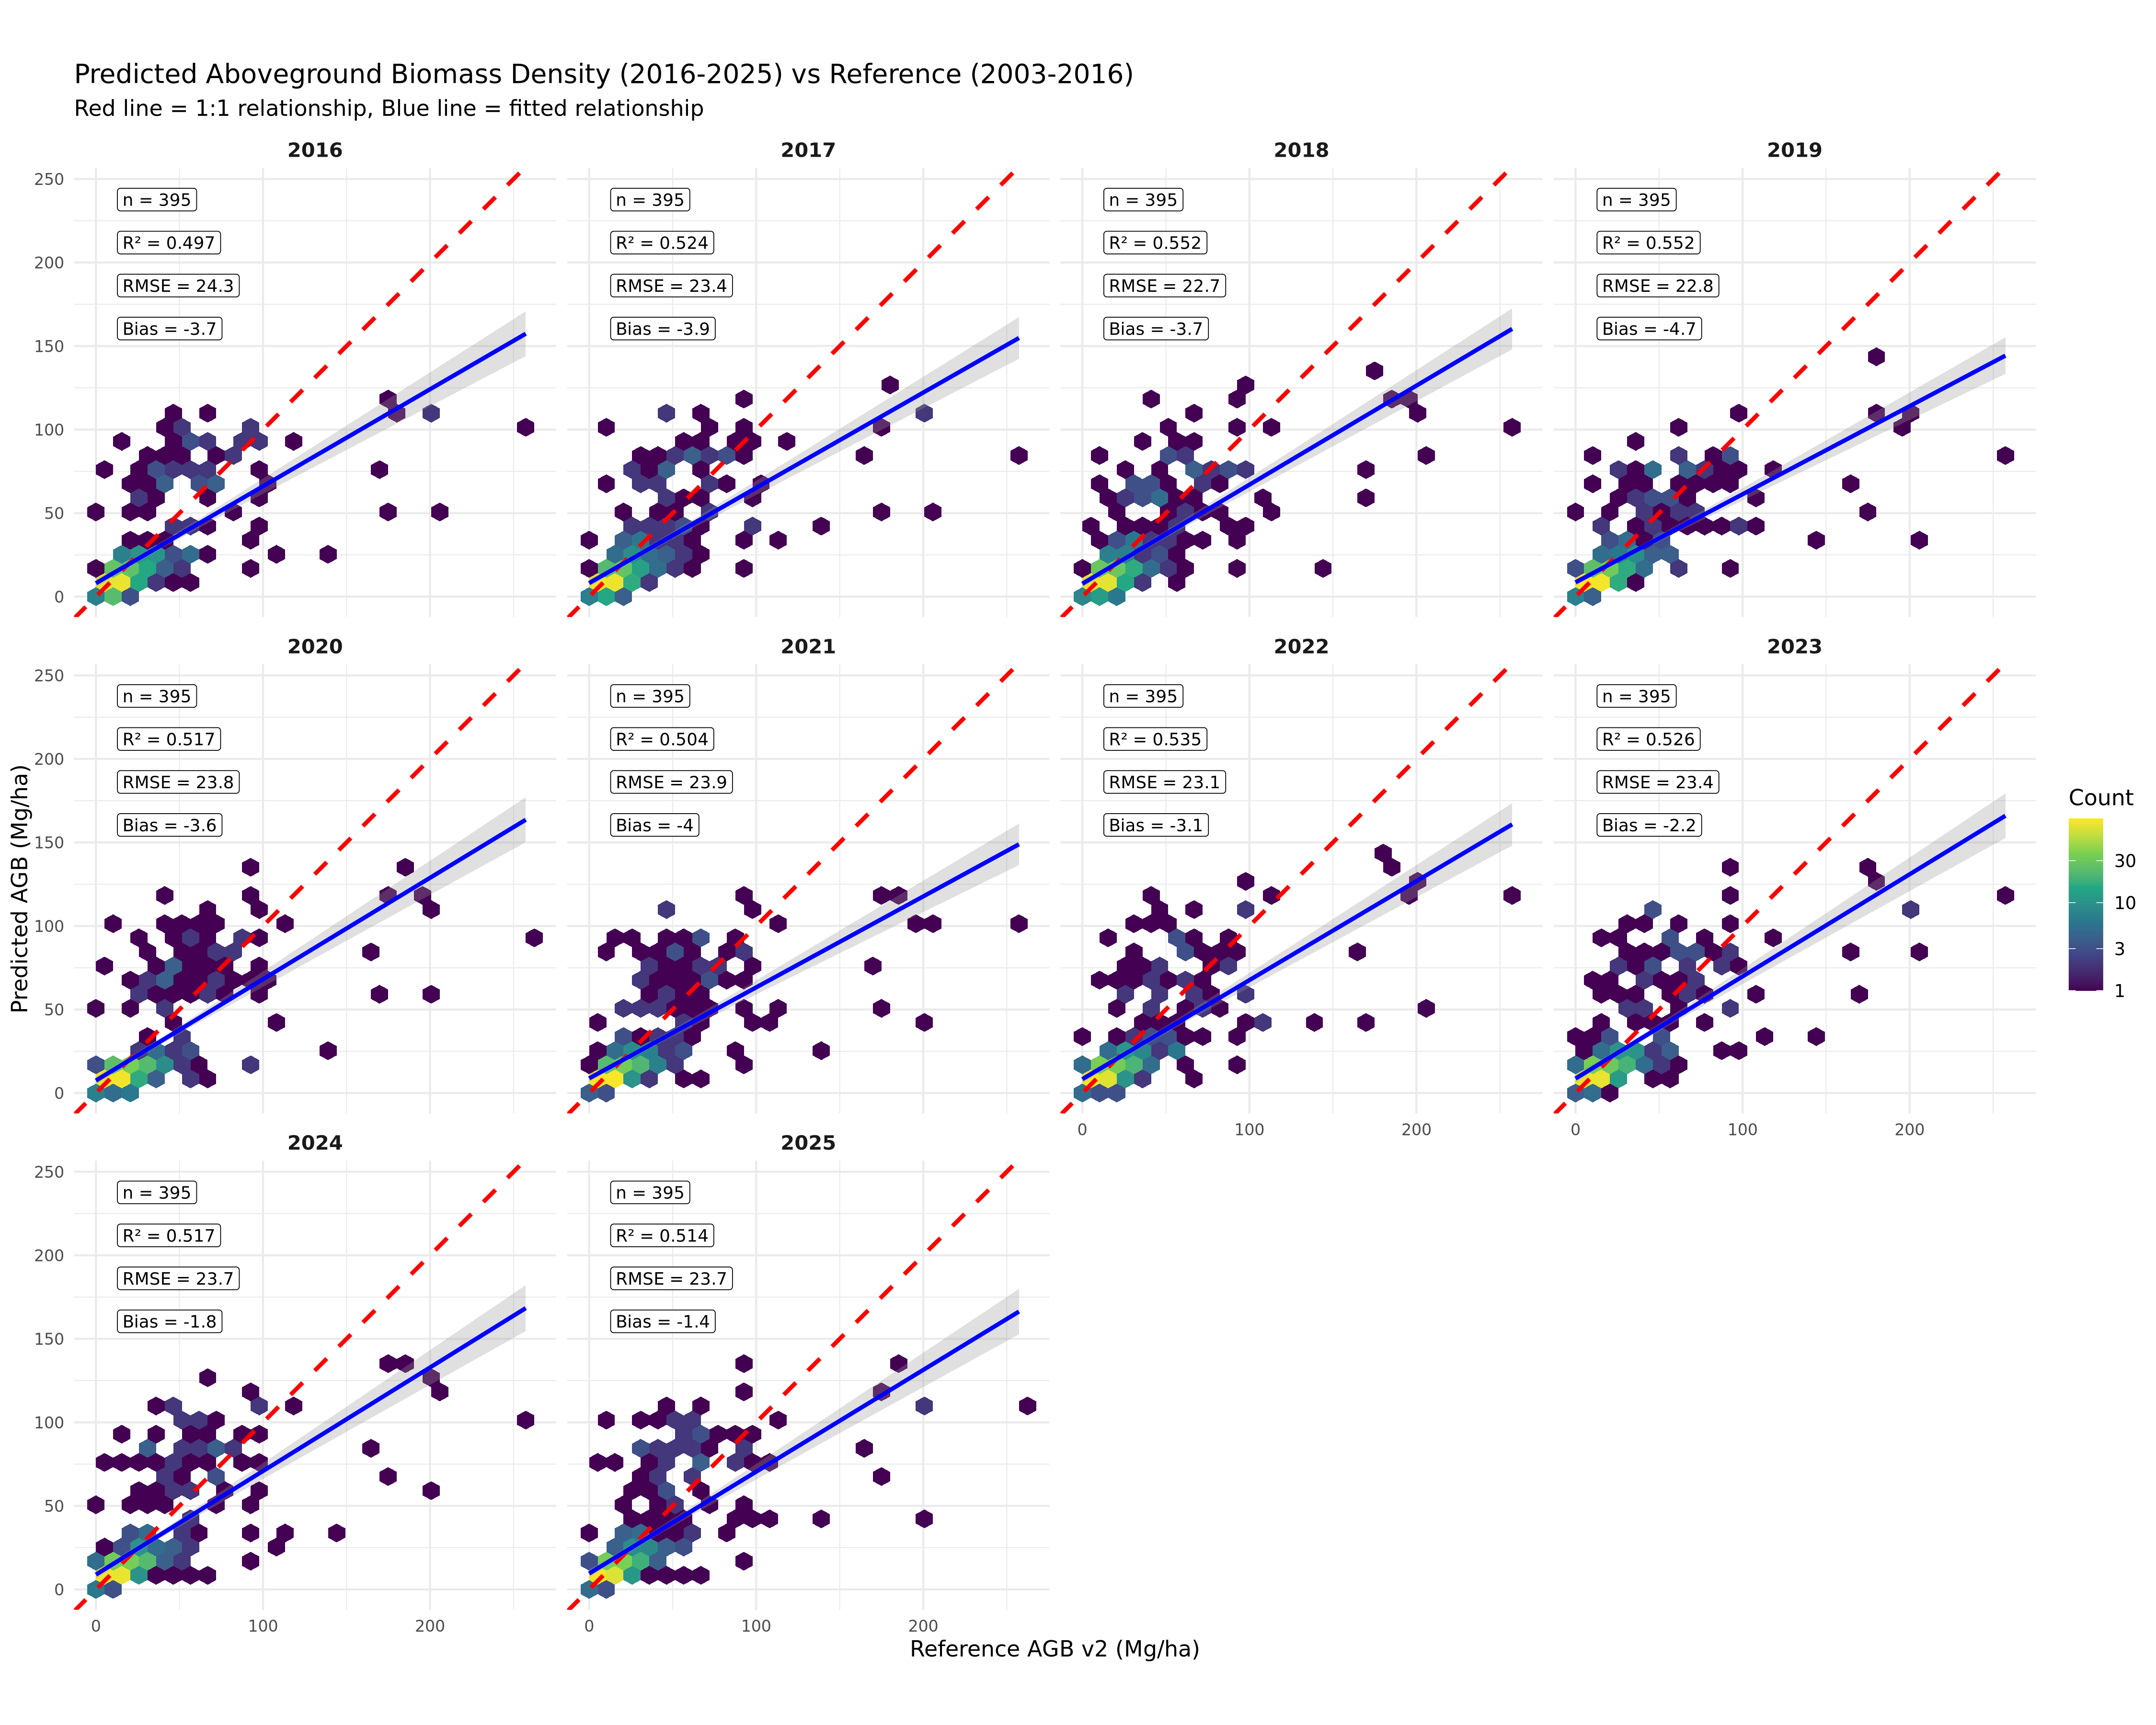

In [112]:
# Calculate statistics for each prediction year
stats_by_year <- plots_long %>%
    filter(group_name != 'West Siberian Plains') %>%
  dplyr::group_by(prediction_year) %>%
  dplyr::summarise(
    n = dplyr::n(),
    r2 = round(cor(agbd_v2_mg_ha, predicted_agb, use = "complete.obs")^2, 3),
    rmse = round(sqrt(mean((predicted_agb - agbd_v2_mg_ha)^2, na.rm = TRUE)), 1),
    bias = round(mean(predicted_agb - agbd_v2_mg_ha, na.rm = TRUE), 1),
    .groups = 'drop'
  )

# Get max values for label positioning
agb_max <- max(c(plots_long$agbd_v2_mg_ha, plots_long$predicted_agb), na.rm = TRUE)

# Faceted hex bin plot with statistics
ggplot(plots_long, aes(x = agbd_v2_mg_ha, y = predicted_agb)) +
  geom_hex(bins = 25) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed", size = 1) +
  geom_smooth(method = "lm", se = TRUE, color = "blue", alpha = 0.3) +
  # Add statistics labels
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.95, 
                 label = paste0("n = ", n)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, label.size = 0.2) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.85, 
                 label = paste0("R² = ", r2)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, label.size = 0.2) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.75, 
                 label = paste0("RMSE = ", rmse)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, label.size = 0.2) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.65, 
                 label = paste0("Bias = ", bias)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, label.size = 0.2) +
  facet_wrap(~prediction_year,
             #scales = "free",
             ncol = 4) +
  scale_fill_viridis_c(name = "Count", trans = "log10") +
  labs(title = "Predicted Aboveground Biomass Density (2016-2025) vs Reference (2003-2016)",
       subtitle = "Red line = 1:1 relationship, Blue line = fitted relationship",
       x = "Reference AGB v2 (Mg/ha)",
       y = "Predicted AGB (Mg/ha)") +
  theme_minimal() +
  coord_equal() +
  theme(axis.text = element_text(size = 8),
        strip.text = element_text(size = 10, face = "bold"))

# Optional: Print the statistics table
print(stats_by_year)

`geom_smooth()` using formula = 'y ~ x'


# A tibble: 10 × 5
   prediction_year     n    r2  rmse  bias
   <chr>           <int> <dbl> <dbl> <dbl>
 1 2016              395 0.497  24.3  -3.7
 2 2017              395 0.524  23.4  -3.9
 3 2018              395 0.552  22.7  -3.7
 4 2019              395 0.552  22.8  -4.7
 5 2020              395 0.517  23.8  -3.6
 6 2021              395 0.504  23.9  -4  
 7 2022              395 0.535  23.1  -3.1
 8 2023              395 0.526  23.4  -2.2
 9 2024              395 0.517  23.7  -1.8
10 2025              395 0.514  23.7  -1.4


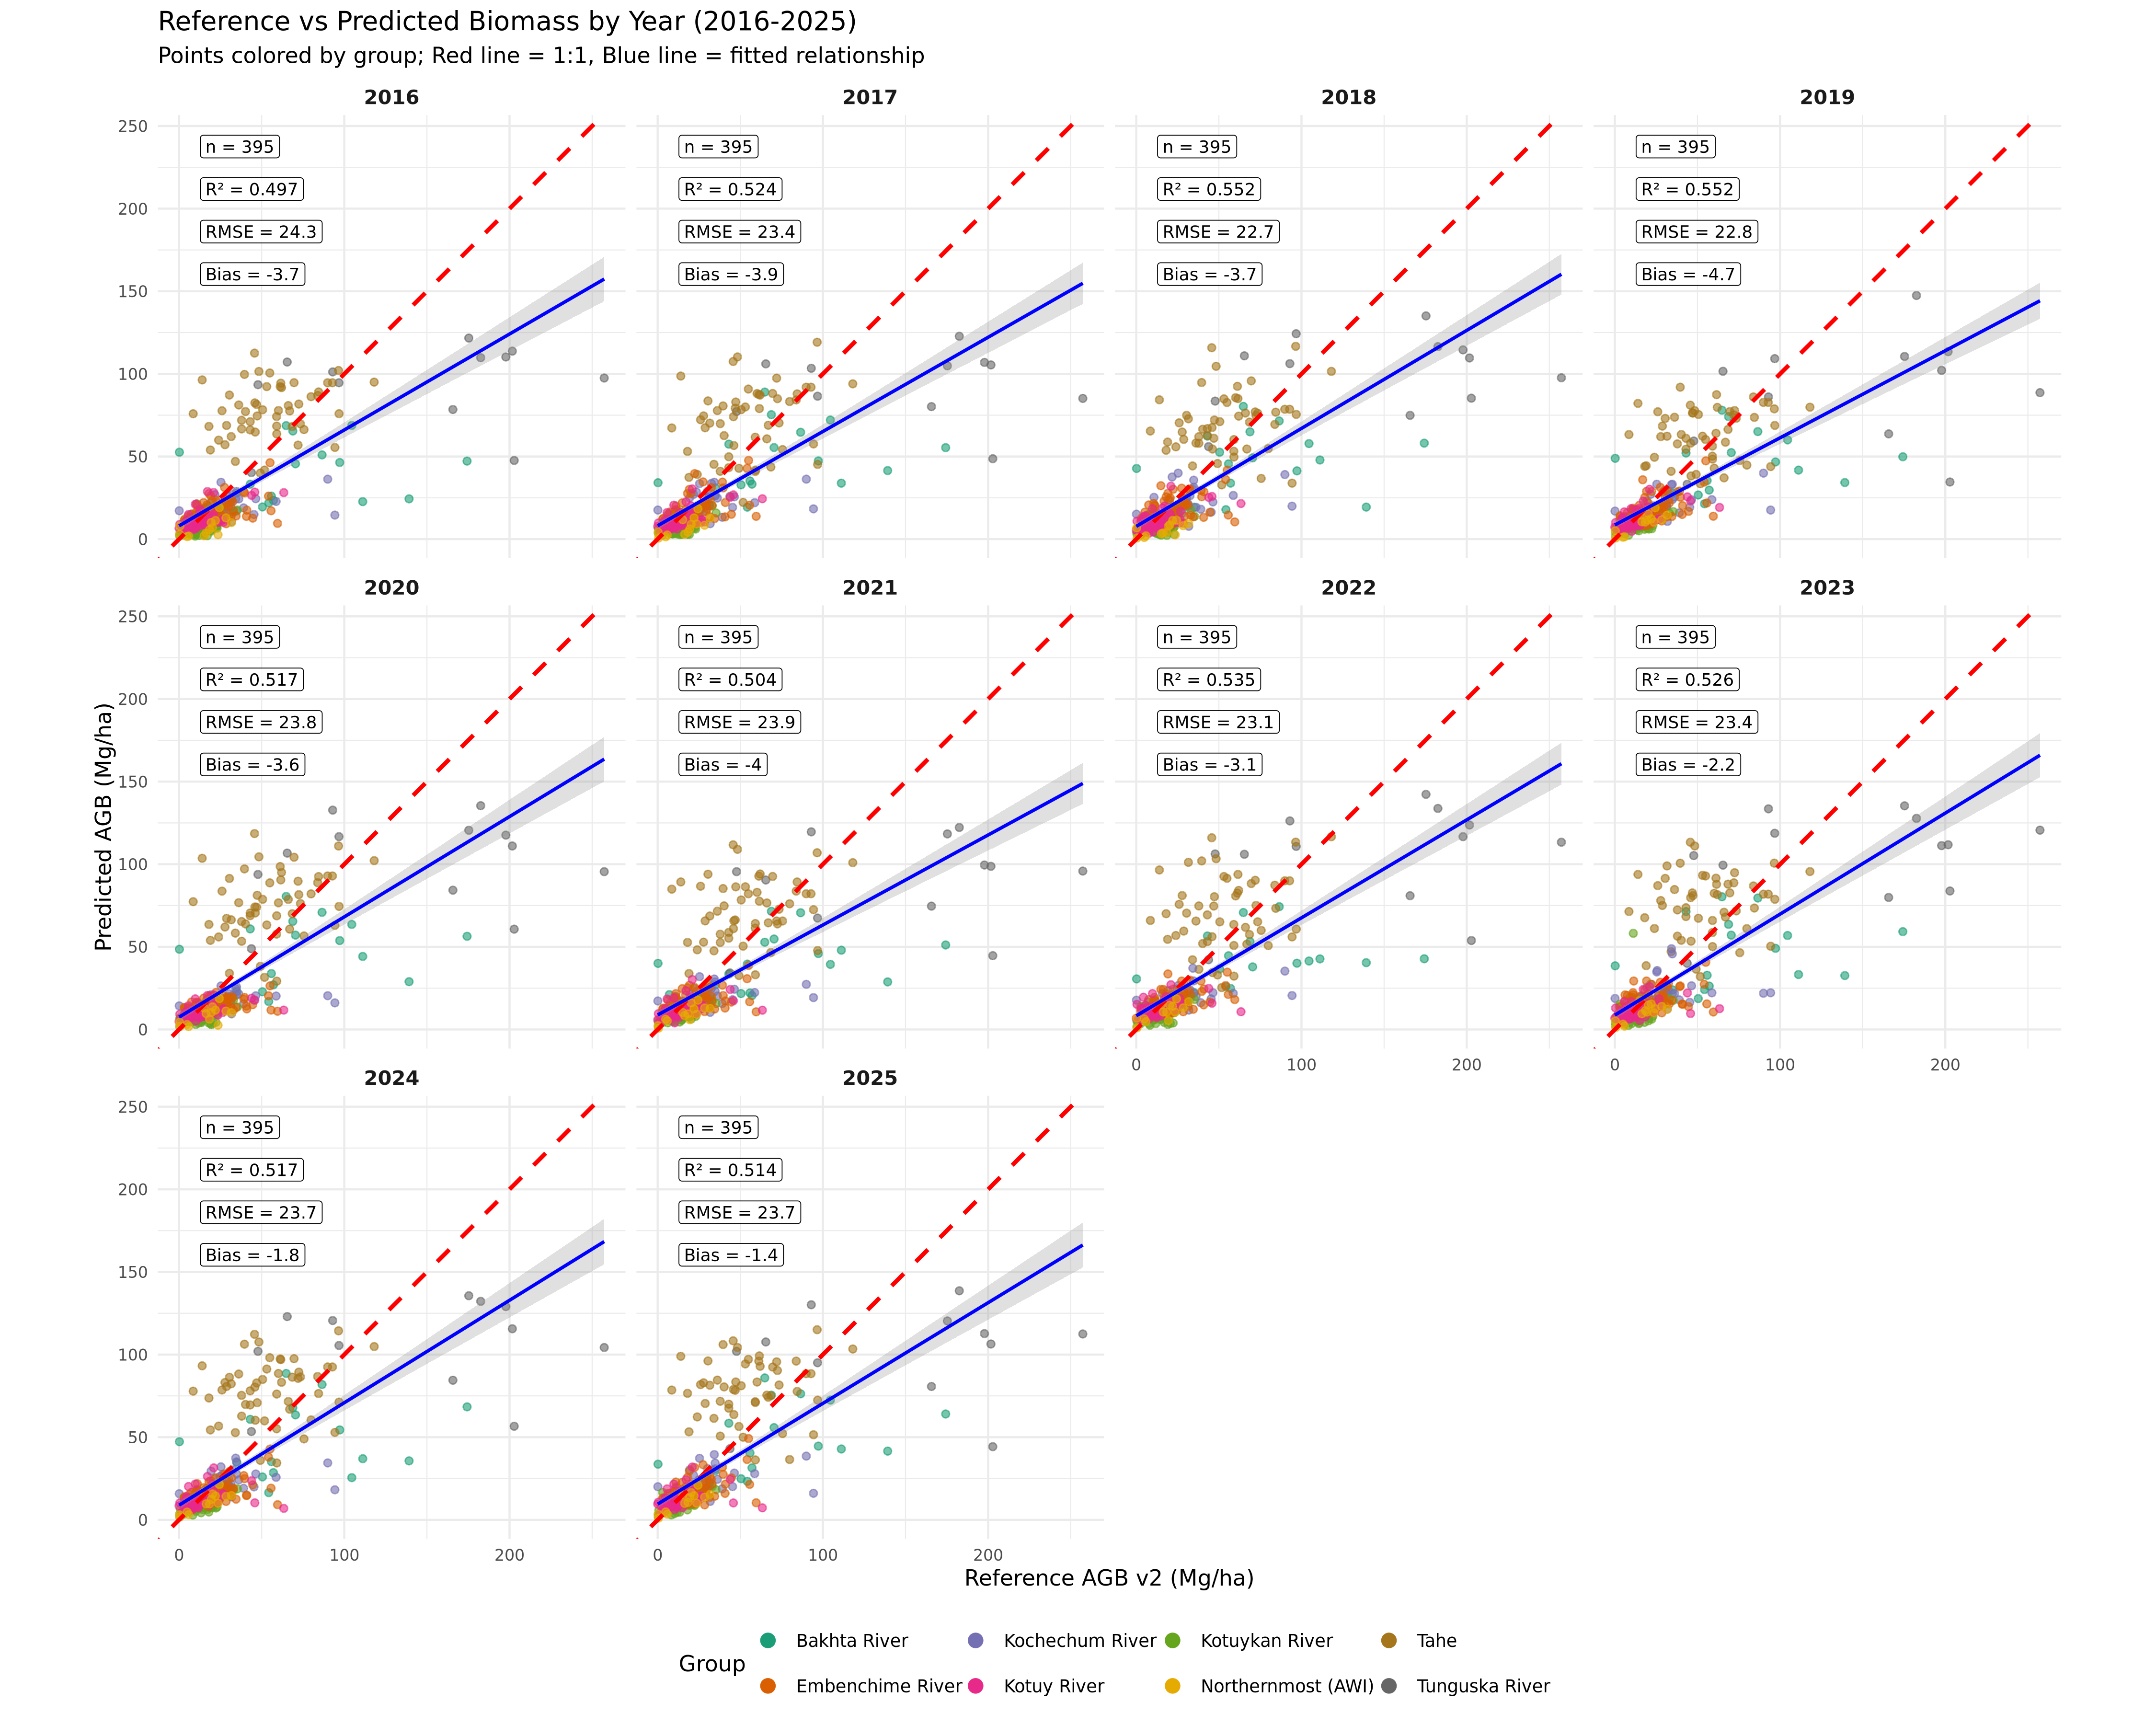

In [113]:
# Ensure group_name is a factor with consistent levels for coloring
plots_long$group_name <- factor(plots_long$group_name)

# Create color palette for groups (matching your existing palette)
num_groups = length(unique(plots_long$group_name))
pal_groups = colorRampPalette(brewer.pal(8, "Dark2"))(num_groups)
names(pal_groups) <- levels(plots_long$group_name)

# Calculate statistics for each prediction year (same as before)
stats_by_year <- plots_long %>%
  dplyr::group_by(prediction_year) %>%
  dplyr::summarise(
    n = dplyr::n(),
    r2 = round(cor(agbd_v2_mg_ha, predicted_agb, use = "complete.obs")^2, 3),
    rmse = round(sqrt(mean((predicted_agb - agbd_v2_mg_ha)^2, na.rm = TRUE)), 1),
    bias = round(mean(predicted_agb - agbd_v2_mg_ha, na.rm = TRUE), 1),
    .groups = 'drop'
  )

# Get max values for label positioning
agb_max <- max(c(plots_long$agbd_v2_mg_ha, plots_long$predicted_agb), na.rm = TRUE)

# Scatterplot with points colored by group_name
ggplot(plots_long, aes(x = agbd_v2_mg_ha, y = predicted_agb, color = group_name)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed", size = 1) +
  geom_smooth(method = "lm", se = TRUE, color = "blue", alpha = 0.3, size = 0.8) +
  # Add statistics labels
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.95, 
                 label = paste0("n = ", n)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, 
             label.size = 0.2, inherit.aes = FALSE) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.85, 
                 label = paste0("R² = ", r2)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, 
             label.size = 0.2, inherit.aes = FALSE) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.75, 
                 label = paste0("RMSE = ", rmse)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, 
             label.size = 0.2, inherit.aes = FALSE) +
  geom_label(data = stats_by_year,
             aes(x = agb_max * 0.05, y = agb_max * 0.65, 
                 label = paste0("Bias = ", bias)),
             hjust = "left", vjust = "top", size = 3,
             color = "black", fill = "white", alpha = 0.8, 
             label.size = 0.2, inherit.aes = FALSE) +
  facet_wrap(~prediction_year, ncol = 4) +
  scale_color_manual(values = pal_groups, name = "Group") +
  labs(title = "Reference vs Predicted Biomass by Year (2016-2025)",
       subtitle = "Points colored by group; Red line = 1:1, Blue line = fitted relationship",
       x = "Reference AGB v2 (Mg/ha)",
       y = "Predicted AGB (Mg/ha)") +
  theme_minimal() +
  coord_equal() +
  theme(axis.text = element_text(size = 8),
        strip.text = element_text(size = 10, face = "bold"),
        legend.position = "bottom") +
  guides(color = guide_legend(override.aes = list(alpha = 1, size = 3)))

# Optional: Print the statistics table
print(stats_by_year)

In [114]:
# More flexible function for biomass validation with improved labeling
DO_FILT_MELT_BIOMASS <- function(val_plots_df, MAX_DIFF_YR, IDVARS, MEAS_VARS, 
                                 FACET_X = NULL, FACET_Y = NULL, YEAR_RS_FILTER=NULL){
    
    # Filter by max year difference (if diff columns exist)
    df_filt = val_plots_df %>% 
        filter(if_all(starts_with("diff_"), ~ is.na(.) | abs(.) <= MAX_DIFF_YR, .default = TRUE)) %>%
        select(!starts_with("diff_"))
    
    print(paste("# of plots after max year diff filter =", MAX_DIFF_YR, ":", nrow(df_filt)))
    
    # Melted DF
    val_plots_m = reshape2::melt(df_filt, 
                       id.vars = IDVARS, 
                       measure.vars = MEAS_VARS) %>% 
        # Extract year from variable name (format: value_AGB_H30_<YYYY>*)
        mutate(year_rs = as.numeric(str_extract(variable, "(?<=H30_)\\d{4}(?=_)"))) %>%
        mutate(map_version = str_extract(variable, "(?<=\\d{4}_).*$")) %>%
        mutate(pred_year_label = as.character(year_rs))  # Just the year, no "Predicted"
    
    # Add region classification only if group_name exists
    if("group_name" %in% names(val_plots_m)) {
        val_plots_m <- val_plots_m %>%
            mutate(region = case_when(
                group_name %in% c('West Siberian Plains', 'Bakhta River','Tunguska River','Tahe','Russian Far East') ~ 'Boreal',
                group_name %in% c('Atlantic Maritime','Pacific Maritime','Mixedwood Plains') ~ 'Temperate',
                TRUE ~ 'Permafrost\nBoreal'
            ))
    } else {
        val_plots_m$region <- 'All Sites'
    }
    
    # Continue with calculations
    val_plots_m <- val_plots_m %>%
        # Calculate differences (assumes reference column is named consistently)
        mutate(diff_agb = value - get(IDVARS[grepl("agbd|biomass", IDVARS)])) %>%
        mutate(diff_yr = year_rs - as.numeric(year)) %>%
        # Filter out -9999 values
        filter(value != -9999, 
               get(IDVARS[grepl("agbd|biomass", IDVARS)]) != -9999)

    # Apply YEAR_RS_FILTER if provided
    if(!is.null(YEAR_RS_FILTER)) {
        val_plots_m = val_plots_m %>% filter(year_rs %in% YEAR_RS_FILTER)
        print(paste("# of rows after year_rs filter (", paste(YEAR_RS_FILTER, collapse=", "), "):", nrow(val_plots_m)))
    }

    # Create group labels for boxplots (if group_name exists)
    if("group_name" %in% names(val_plots_m)) {
        group_labels <- val_plots_m %>%
            group_by(diff_yr, group_name, pred_year_label) %>%
            summarise(
                median_diff = median(diff_agb, na.rm = TRUE),
                max_diff = max(diff_agb, na.rm = TRUE),
                label_y = max_diff + 5,  # Position labels above boxplots
                .groups = 'drop'
            )
    }

    # Determine faceting formula
    if(!is.null(FACET_Y) && !is.null(FACET_X)) {
        facet_formula <- paste(FACET_Y, "~", FACET_X)
        group_vars <- c(FACET_Y, FACET_X)
    } else if(!is.null(FACET_X)) {
        facet_formula <- paste(".", "~", FACET_X)
        group_vars <- FACET_X
    } else if(!is.null(FACET_Y)) {
        facet_formula <- paste(FACET_Y, "~", ".")
        group_vars <- FACET_Y
    } else {
        facet_formula <- NULL
        group_vars <- NULL
    }

    # Boxplot timeline
    p_box_timeline = ggplot(val_plots_m) +
        geom_boxplot(aes(y=diff_agb, x=diff_yr, fill=as.numeric(year), group=interaction(year, diff_yr)), 
                     outlier.size=0.5, alpha=0.7) +
        geom_hline(aes(yintercept=0), linetype='dashed', color='red') +
        geom_vline(aes(xintercept=0), linetype='dashed', color='blue') +
        scale_fill_viridis_c(option='plasma', name='Year of\nplot obs.', limits = c(2003, 2016)) +  # Updated limits
        coord_cartesian(ylim=c(-75, 75)) +
        labs(y='Difference (AGB, Mg/ha)\n[satellite - field]', 
             x='Difference (years) between observations\n[satellite - field]',
             title='Timeline of Biomass Prediction Differences') +
        theme_bw()
    
    # Add group name labels if group_name exists
    if("group_name" %in% names(val_plots_m) && exists("group_labels")) {
        p_box_timeline <- p_box_timeline +
            geom_text(data=group_labels, 
                      aes(x=diff_yr, y=-label_y, label=group_name),
                      size=2, angle=90, hjust=0, vjust=-0.5, color="black")
    }
    
    # Add faceting if specified
    if(!is.null(facet_formula)) {
        p_box_timeline <- p_box_timeline + facet_grid(as.formula(facet_formula), scales = "free_x")
    }

    # Drop NA for hex plot
    val_plots_m_clean = val_plots_m %>% drop_na()
    
    # Calculate statistics for labeling
    if(!is.null(group_vars)) {
        df_stats <- val_plots_m_clean %>%
            group_by(across(all_of(group_vars))) %>%
            summarise(
                n = n(),  # This counts the number of observations
                r2 = round(cor(get(IDVARS[grepl("agbd|biomass", IDVARS)]), value, use="complete.obs")^2, 3),
                rmse = round(sqrt(mean((value - get(IDVARS[grepl("agbd|biomass", IDVARS)]))^2, na.rm=TRUE)), 1),
                mean_bias = round(mean(value - get(IDVARS[grepl("agbd|biomass", IDVARS)]), na.rm=TRUE), 1),
                .groups = 'drop'
            )
    } else {
         df_stats <- val_plots_m_clean %>%
            summarise(
                n = n(),  # This counts the number of observations
                r2 = round(cor(get(IDVARS[grepl("agbd|biomass", IDVARS)]), value, use="complete.obs")^2, 3),
                rmse = round(sqrt(mean((value - get(IDVARS[grepl("agbd|biomass", IDVARS)]))^2, na.rm=TRUE)), 1),
                mean_bias = round(mean(value - get(IDVARS[grepl("agbd|biomass", IDVARS)]), na.rm=TRUE), 1)
            )
    }
    
    # Hex scatterplot
    ref_col <- IDVARS[grepl("agbd|biomass", IDVARS)]
    agbmax = max(c(val_plots_m_clean[[ref_col]], val_plots_m_clean$value), na.rm=TRUE)
    label_text_sz = 2.5
    
    p_hex_scat = ggplot(val_plots_m_clean, aes(x=.data[[ref_col]], y=value)) +
        geom_hex(bins=30) +
        geom_abline(slope=1, intercept=0, color="red", linetype="dashed", size=0.8) +
        geom_smooth(method="lm", se=TRUE, color="blue", alpha=0.3, size=0.8) +
        scale_fill_viridis_c(name="Count", trans="log10") +
        labs(x=paste("Reference AGB (Mg/ha, ",ref_col,")"), 
             y="Predicted AGB (Mg/ha)",
             title="Predicted Aboveground Biomass Density (2016-2025) vs Reference (2003-2016)") +
        theme_minimal()
    
    # Add statistics labels if we have faceting
    if(!is.null(group_vars)) {
        p_hex_scat <- p_hex_scat +
            geom_label(data=df_stats, 
                       mapping=aes(x = agbmax*0.1, y = agbmax*0.95, label=paste("n =", n)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(data=df_stats, 
                       mapping=aes(x = agbmax*0.1, y = agbmax*0.85, label=paste("R² =", r2)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(data=df_stats, 
                       mapping=aes(x = agbmax*0.1, y = agbmax*0.75, label=paste("RMSE =", rmse)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(data=df_stats, 
                       mapping=aes(x = agbmax*0.1, y = agbmax*0.65, label=paste("Mean Bias =", mean_bias)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2)
    } else {
        # For non-faceted plots, add single label
        p_hex_scat <- p_hex_scat +
            geom_label(mapping=aes(x = agbmax*0.1, y = agbmax*0.95, label=paste("n =", df_stats$n)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(mapping=aes(x = agbmax*0.1, y = agbmax*0.85, label=paste("R² =", df_stats$r2)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(mapping=aes(x = agbmax*0.1, y = agbmax*0.75, label=paste("RMSE =", df_stats$rmse)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2) +
            geom_label(mapping=aes(x = agbmax*0.1, y = agbmax*0.65, label=paste("Mean Bias =", df_stats$mean_bias)), 
                       hjust="left", vjust="top", size=label_text_sz, 
                       color="black", fill="white", alpha=0.8, label.size=0.2)
    }
    
    # Add faceting if specified
    if(!is.null(facet_formula)) {
        p_hex_scat <- p_hex_scat + facet_wrap(as.formula(facet_formula), ncol=5)
    }

    return(list(val_plots_m_clean, p_box_timeline, p_hex_scat))
}


In [115]:
# Example usage with flexible faceting:
MEAS_VARS <- agb_cols

# Option 1: No faceting
IDVARS1 <- c("site", "year", "agbd_v2_mg_ha")
result1 <- DO_FILT_MELT_BIOMASS(plots_sf, 
                                MAX_DIFF_YR = 25, 
                                IDVARS = IDVARS1, 
                                MEAS_VARS = MEAS_VARS)

# Option 2: Facet by prediction year only
IDVARS2 <- c("site", "year", "agbd_v2_mg_ha")
result2 <- DO_FILT_MELT_BIOMASS(plots_sf, 
                                MAX_DIFF_YR = 25, 
                                IDVARS = IDVARS2, 
                                MEAS_VARS = MEAS_VARS,
                                FACET_Y = "pred_year_label")

# Option 3: Facet by both group and year (if group_name is available)
IDVARS3 <- c("site", "group_name", "year", "agbd_v2_mg_ha")
result3 <- DO_FILT_MELT_BIOMASS(plots_sf, 
                                MAX_DIFF_YR = 25, 
                                IDVARS = IDVARS3, 
                                MEAS_VARS = MEAS_VARS,
                                FACET_X = "group_name",
                                FACET_Y = "pred_year_label")

[1] "# of plots after max year diff filter = 25 : 536"
[1] "# of plots after max year diff filter = 25 : 536"
[1] "# of plots after max year diff filter = 25 : 536"


In [116]:
IDVARS3[grepl("agbd|biomass", IDVARS3)]

[1] "agbd_v2_mg_ha"

In [117]:
MEAS_VARS

[1] "value_AGB_H30_2016_v3.1_multiyr_mean_agbd"
 [2] "value_AGB_H30_2017_v3.1_multiyr_mean_agbd"
 [3] "value_AGB_H30_2018_v3.1_multiyr_mean_agbd"
 [4] "value_AGB_H30_2019_v3.1_multiyr_mean_agbd"
 [5] "value_AGB_H30_2020_v3.1_multiyr_mean_agbd"
 [6] "value_AGB_H30_2021_v3.1_multiyr_mean_agbd"
 [7] "value_AGB_H30_2022_v3.1_multiyr_mean_agbd"
 [8] "value_AGB_H30_2023_v3.1_multiyr_mean_agbd"
 [9] "value_AGB_H30_2024_v3.1_multiyr_mean_agbd"
[10] "value_AGB_H30_2025_v3.1_multiyr_mean_agbd"

[1] "# of plots after max year diff filter = 25 : 536"


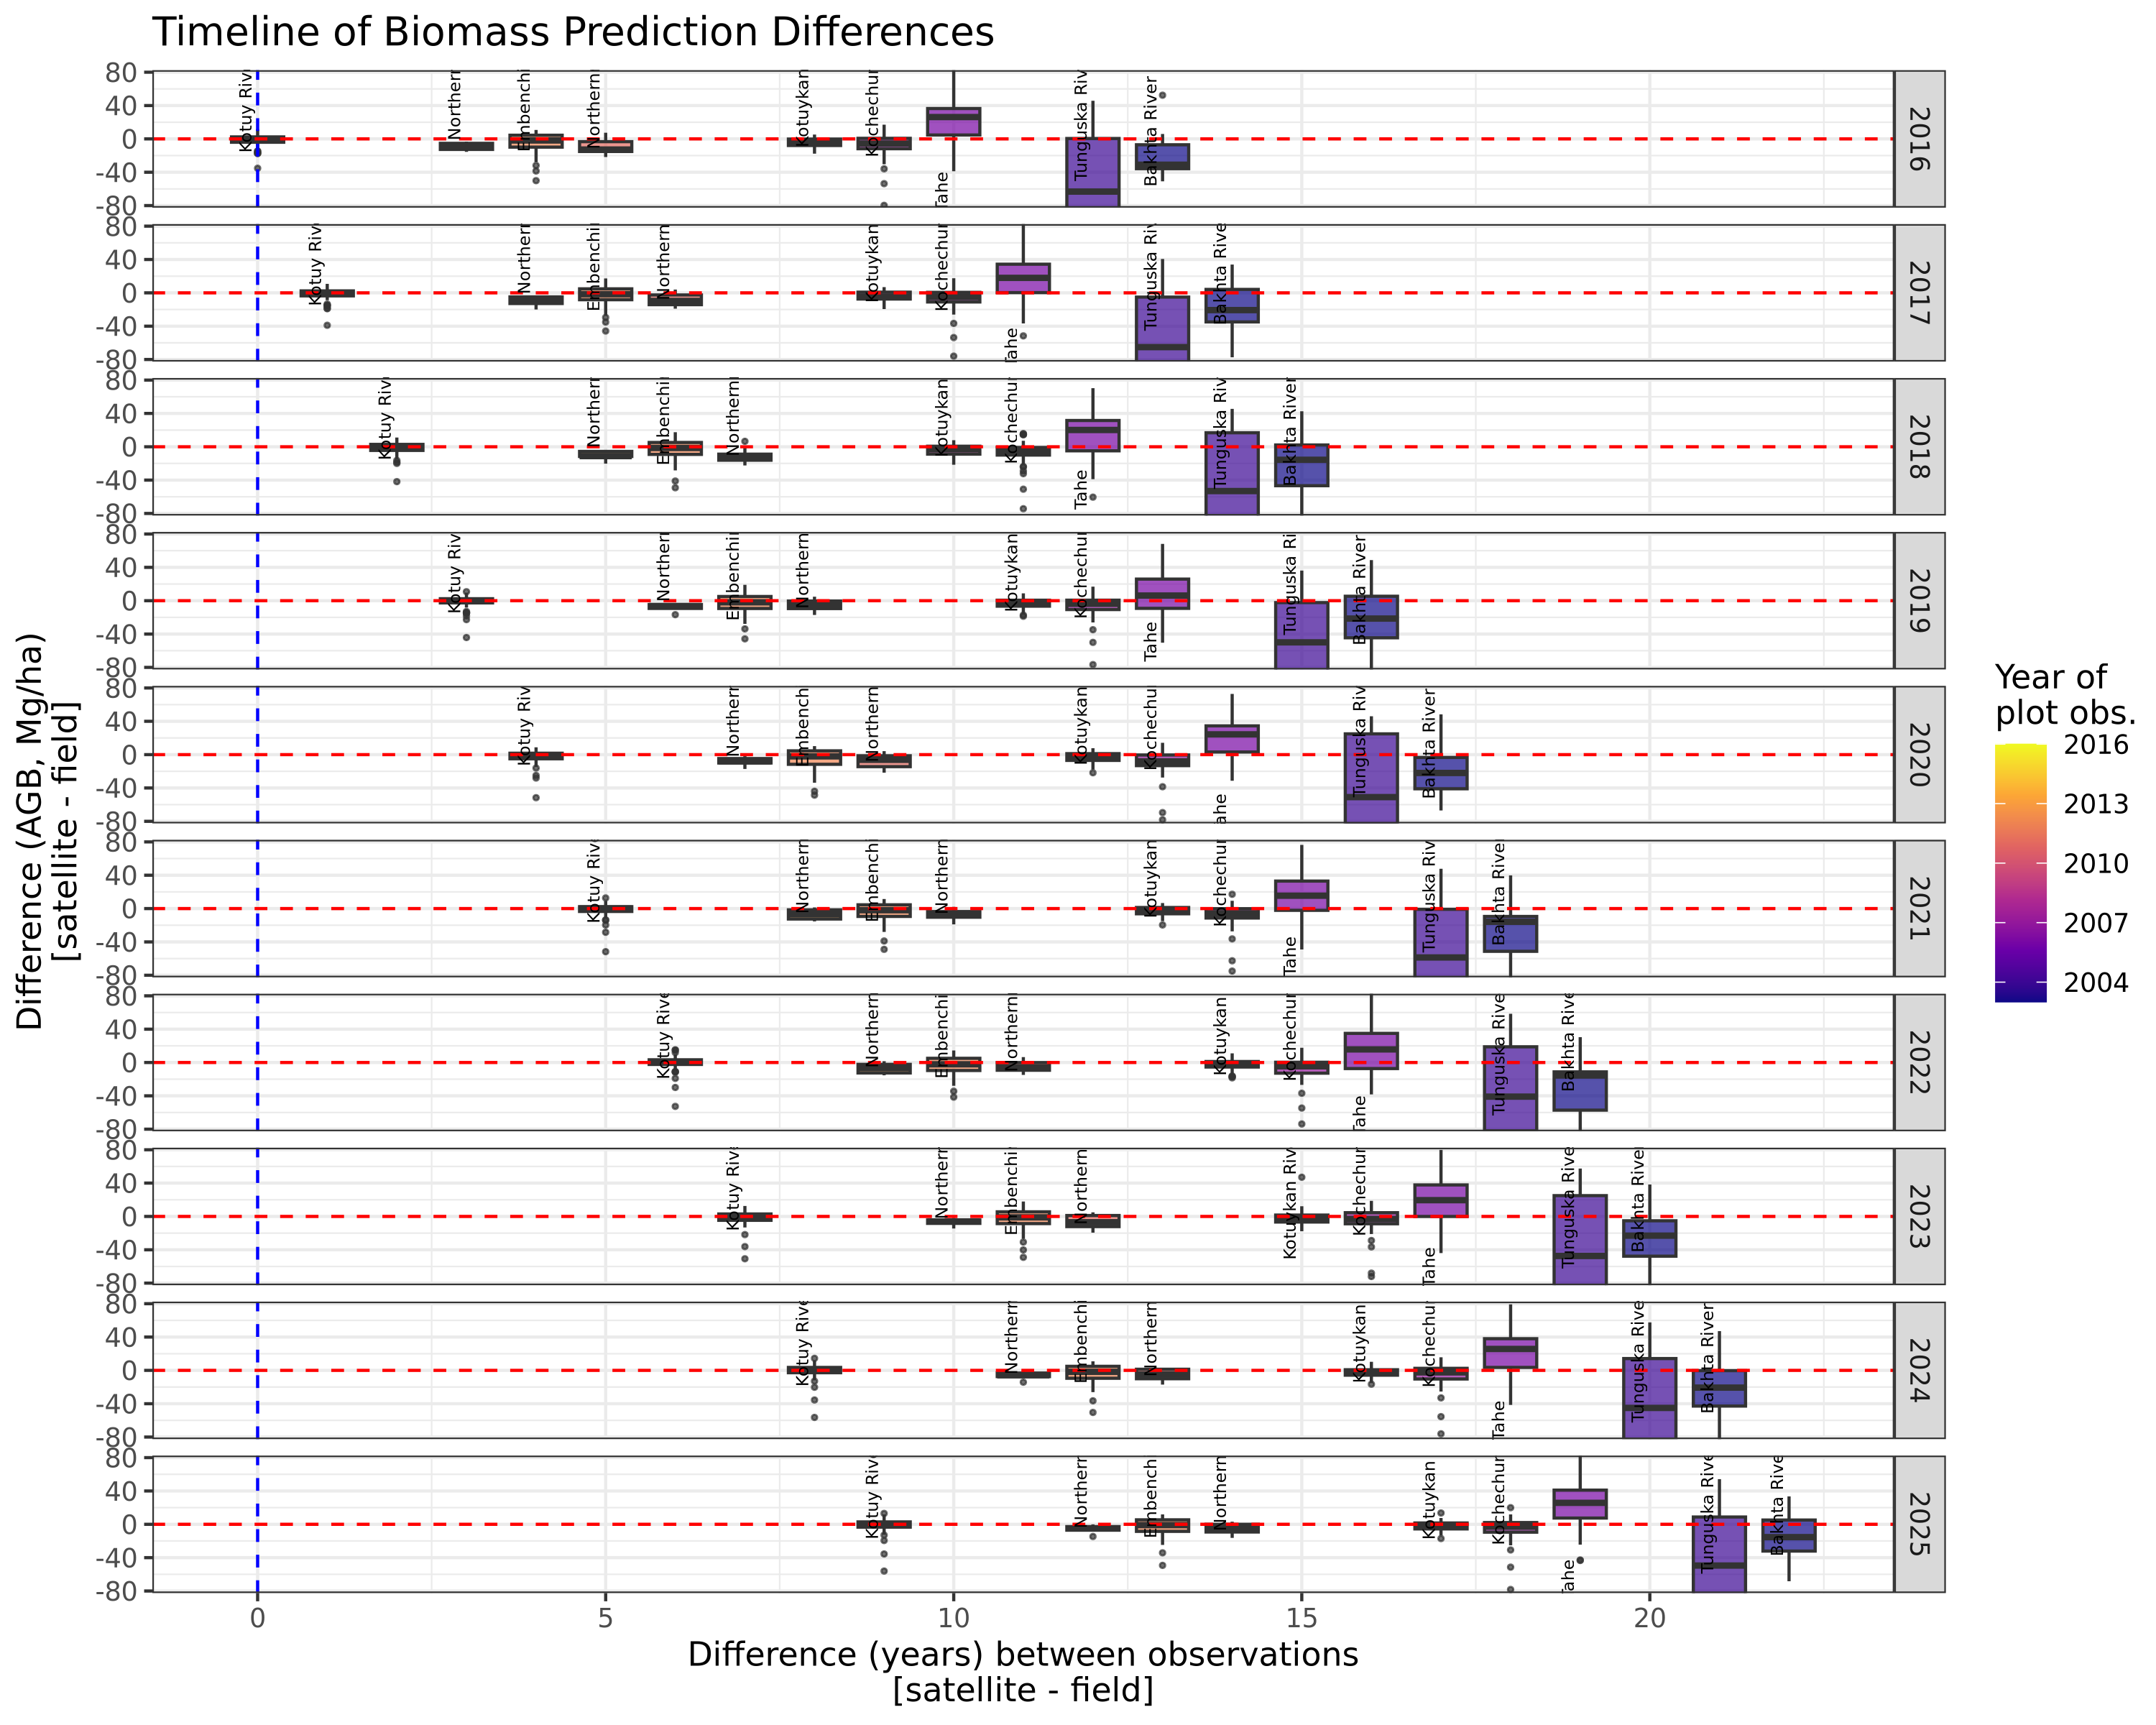

In [118]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 300)

# Usage example:
IDVARS3 <- c("site", 
             "group_name",
             "year", "agbd_v2_mg_ha")
result3 <- DO_FILT_MELT_BIOMASS(plots_sf %>% filter(group_name != 'West Siberian Plains'), 
                                MAX_DIFF_YR = 25, 
                                IDVARS = IDVARS3, 
                                #MEAS_VARS = c('value_AGB_H30_2016_v3.1_multiyr_mean_agbd','value_AGB_H30_2020_v3.1_multiyr_mean_agbd', 'value_AGB_H30_2025_v3.1_multiyr_mean_agbd'),
                                MEAS_VARS = MEAS_VARS,
                                #FACET_X = "group_name",
                                FACET_Y = "pred_year_label")

print(result3[[2]])  # boxplot timeline with group labels

`geom_smooth()` using formula = 'y ~ x'


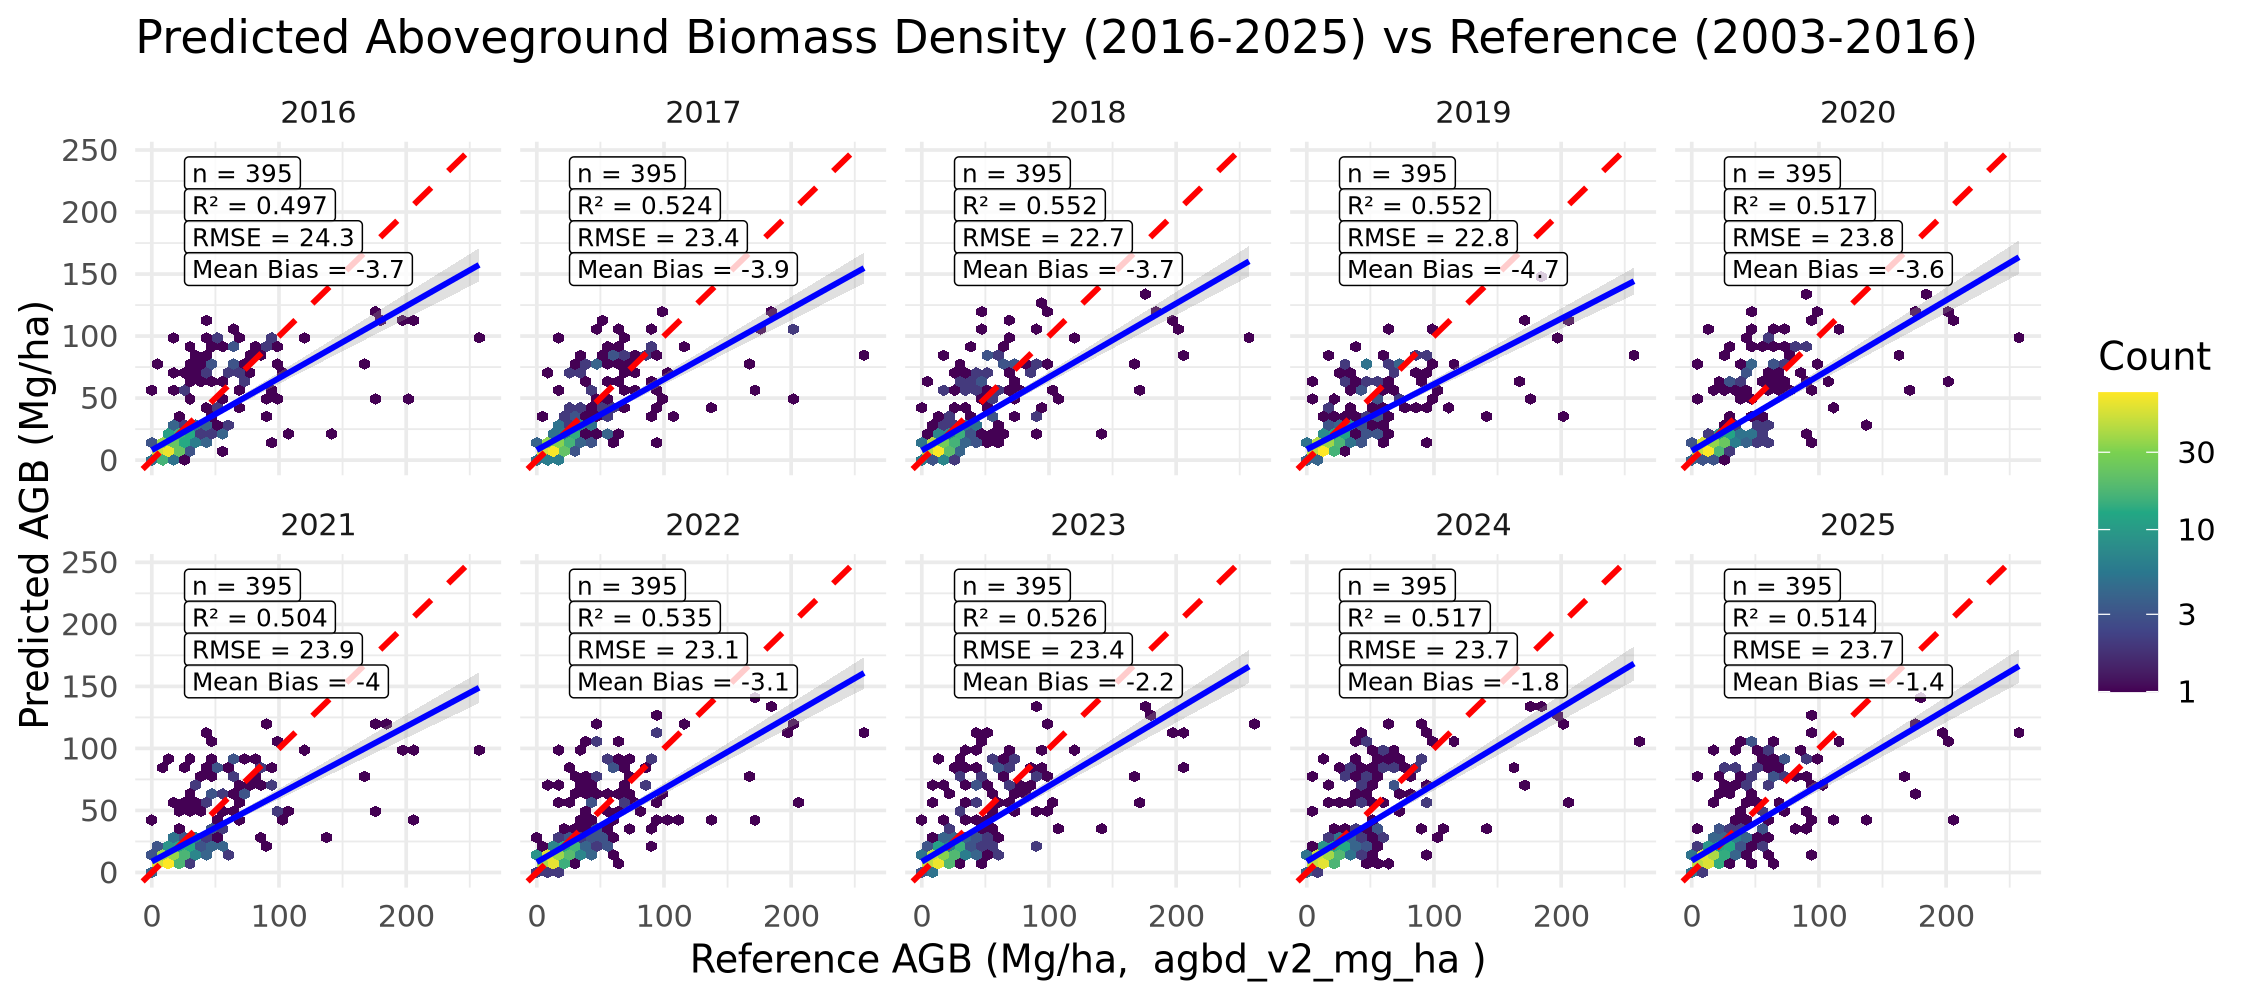

In [119]:
options(repr.plot.width = 9, repr.plot.height = 4, repr.plot.res = 250)

print(result3[[3]])

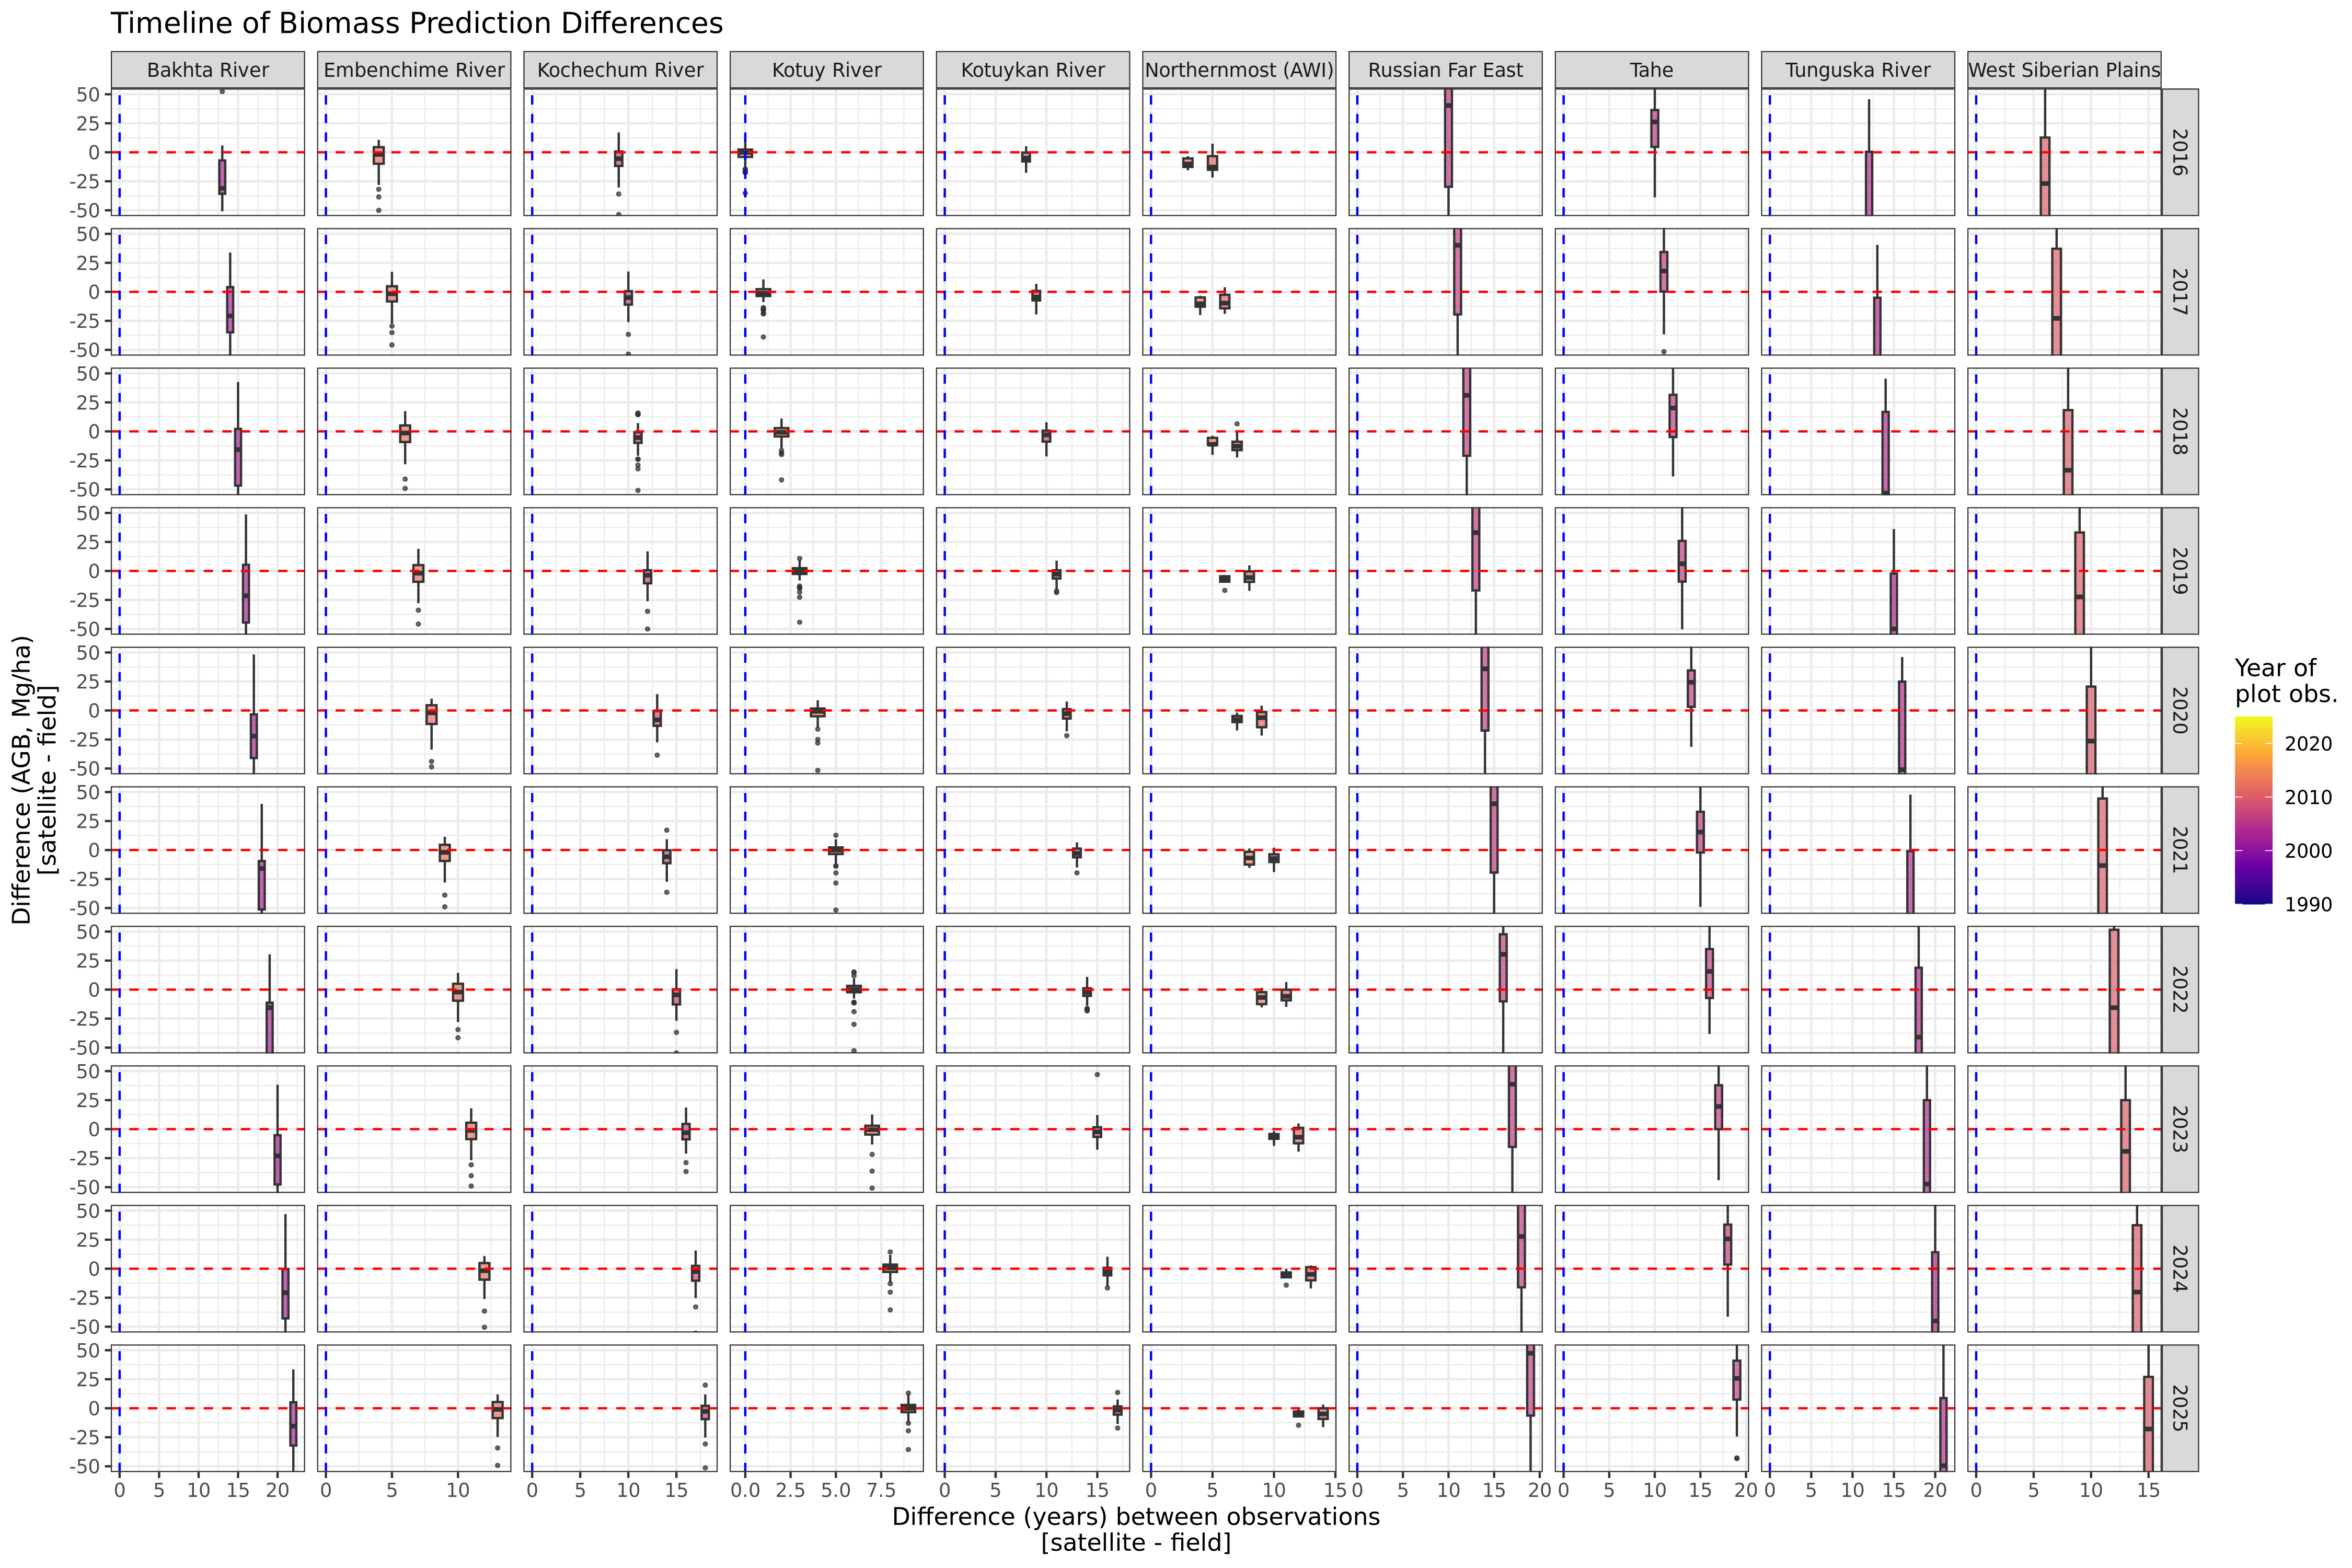

In [34]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 300)

# Display plots
print(boxplot_timeline)

In [54]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 300)

print(hex_scatter)

ERROR: Error: object 'hex_scatter' not found
